# Momentum Method. DBN Networks.

In [2]:
# Check for all needed packages
import time

%pip install numpy matplotlib
%pip install mnists

import numpy
import matplotlib
import mnists
# In case of ImportError, install them to the running kernel with
# pip install numpy matplotlib mnists
# or the the runtime container with:
# !pip install numpy matplotlib mnists
# (In case of the latter, remember to restart the kernel!)

# Tested in Python 3.14.3 with:
# numpy==2.4.3
# matplotlib==3.10.8
# mnists==0.4.1

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\womackow\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\womackow\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1234)

try:
    import mkl
    mkl.set_num_threads(2)
except ImportError:
    print("Intel Math Kernel Library (MKL) does not always work on every machine. "
          "Continuing without `mkl`.")

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.rcParams["figure.figsize"] = [16, 9]

Intel Math Kernel Library (MKL) does not always work on every machine. Continuing without `mkl`.


### Handy utility functions

In [4]:
def append_ones(matrix: np.ndarray) -> np.ndarray:
    """
    Appends a column of ones to the right side of a 2D matrix.
    """
    return np.concatenate((matrix, np.ones((matrix.shape[0], 1), dtype=np.float32)), axis=1)


def zeros(*dims: int) -> np.ndarray:
    """
    Creates a NumPy array of zeros with the given shape.

    Args:
        *dims:  Variable number of integers defining the shape of the array.
                E.g. zeros(3, 4) creates a (3, 4) array.
    """
    return np.zeros(shape=tuple(dims), dtype=np.float32)
def ones(*dims: int) -> np.ndarray:
    """
    Creates a NumPy array of ones with the given shape.

    Args:
        *dims:  Variable number of integers defining the shape of the array.
                E.g. ones(3, 4) creates a (3, 4) array.
    """
    return np.ones(shape=tuple(dims), dtype=np.float32)

def rand(*dims: int) -> np.ndarray:
    """
    Creates a NumPy array of random values sampled from a uniform [0, 1) distribution.

    Args:
        *dims:  Variable number of integers defining the shape of the array.
                E.g. rand(3, 4) creates a (3, 4) array.
    """
    return np.random.rand(*dims).astype(np.float32)

def chunks(seq: list, size: int) -> tuple[np.ndarray]:
    """
    Splits a sequence into consecutive chunks of a given size.

    The last chunk may be smaller than `size` if the sequence length
    is not evenly divisible.

    Args:
        seq:  The input sequence (e.g. list or other sliceable) to split.
        size: The maximum number of elements in each chunk.

    Returns:
        Successive sub-sequences of length `size` (or less for the final chunk).
    """
    return tuple([seq[pos:(pos + size)] for pos in range(0, len(seq), size)])

def arrange_tiles_img(examples: np.ndarray) -> np.ndarray:
    """
    Arrange 2D matrices as tiles

    Takes 4D `examples` tensor with dims:
        rows x cols x tile_height x tile_width
    """
    rows_count = examples.shape[0]
    cols_count = examples.shape[1]
    tile_height = examples.shape[2]
    tile_width = examples.shape[3]

    space_between_tiles = 2
    img_matrix = np.empty(shape=(rows_count * (tile_height + space_between_tiles) - space_between_tiles,
                                 cols_count * (tile_width + space_between_tiles) - space_between_tiles))
    img_matrix.fill(np.nan)

    for r in range(rows_count):
        for c in range(cols_count):
            x_0 = r * (tile_height + space_between_tiles)
            y_0 = c * (tile_width + space_between_tiles)
            img_matrix[x_0:x_0 + tile_height, y_0:y_0 + tile_width] = examples[r, c]

    return img_matrix

def preview_tiles(examples: np.ndarray) -> np.ndarray:
    """Previews the arrange tiles"""
    img = arrange_tiles_img(examples)
    plt.matshow(img, cmap='gray', interpolation='none')
    plt.axis('off')
    plt.show()

# MNIST dataset

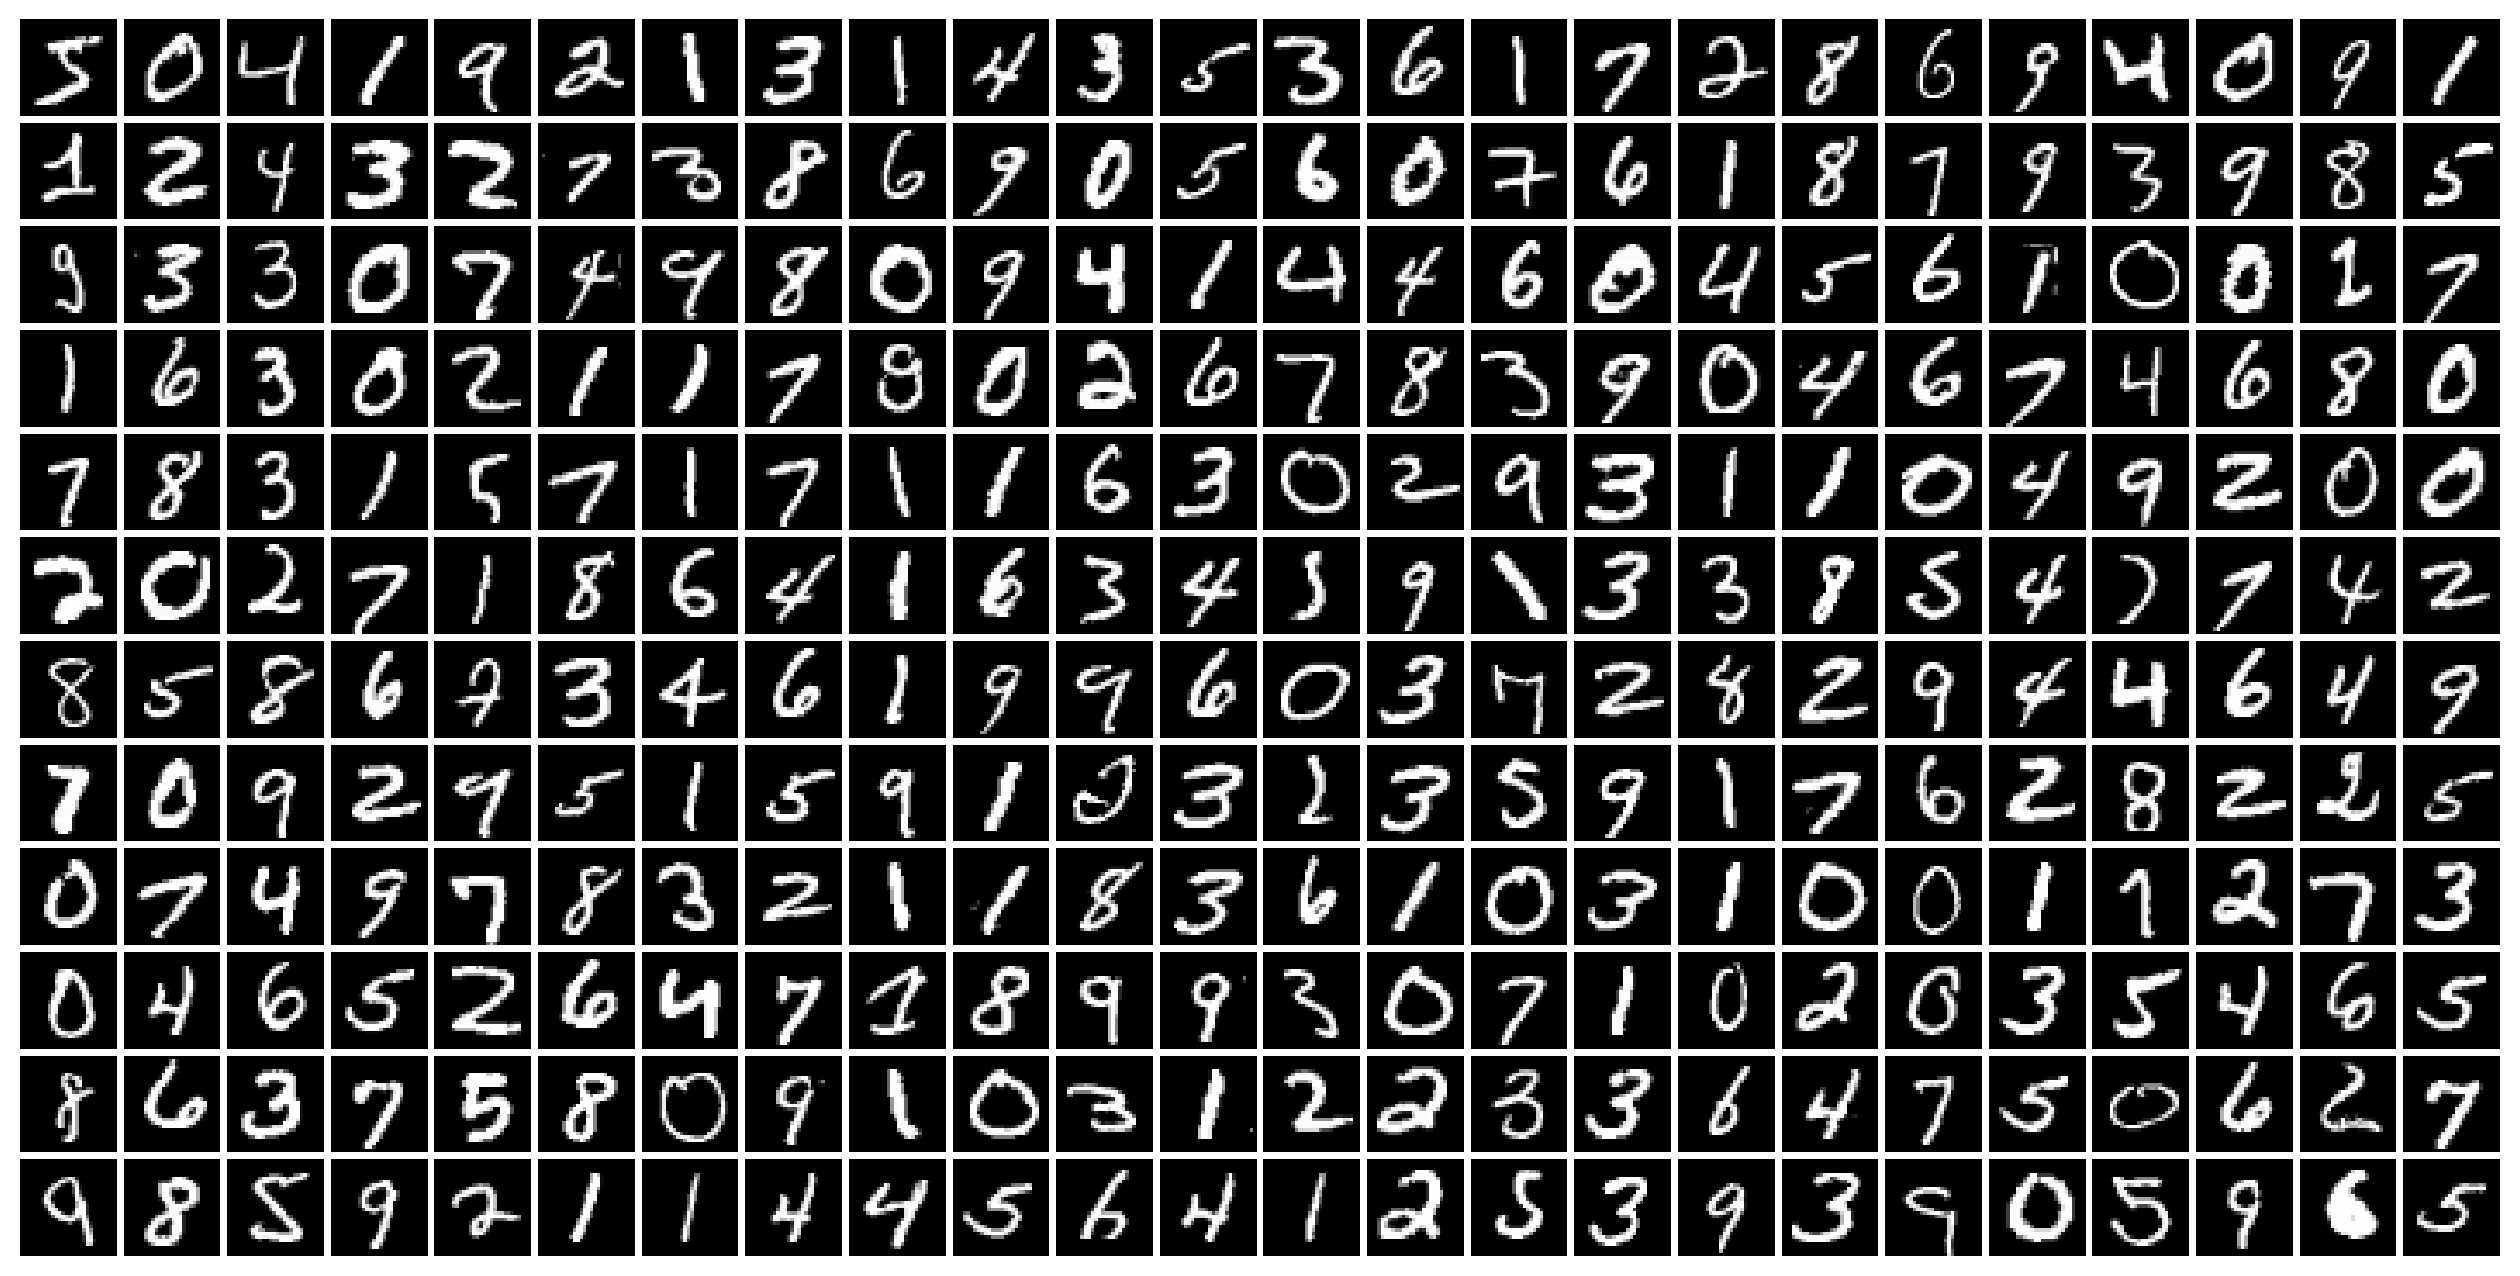

In [5]:
from mnists import MNIST
mnist = MNIST()

PREVIEW_N_ROWS = 12
PREVIEW_N_COLS = 24
TILE_DIM = 28 # [px]

def create_mnist_digits(n_rows: int, n_cols: int, tile_dim: int) -> np.ndarray:
    shape = (n_rows, n_cols, tile_dim, tile_dim)
    return np.reshape(mnist.train_images()[:12*24], shape)

mnist_digits = create_mnist_digits(PREVIEW_N_ROWS, PREVIEW_N_COLS, TILE_DIM)

preview_tiles(mnist_digits)

# Restricted Boltzmann Machine & Contrastive Divergence algorithm

In [6]:
def sigmoid(x: np.ndarray) -> np.ndarray:
    """
    Applies the sigmoid (logistic) activation function element-wise.

    Squashes each value in `x` to the range (0, 1), which is
    interpreted as an activation probability in the RBM context.
    """
    return 1.0 / (1.0 + np.exp(-x))

class RestrictedBoltzmannMachine:
    """
    A Restricted Boltzmann Machine (RBM) with a single visible and hidden layer.

    The weight matrix W has shape (visible_size + 1, hidden_size + 1), where
    the extra row and column are reserved for bias units.

    Attributes:
        visible_size:  Number of visible (input) units, excluding the bias.
        hidden_size:   Number of hidden units, excluding the bias.
        learning_rate: Step size used during contrastive divergence updates.
        W:             Weight matrix of shape (visible_size+1, hidden_size+1).
        momentum:      Momentum coefficient
    """
    def __init__(
        self,
        visible_size: int,
        hidden_size: int,
        learning_rate: float,
        momentum: float = 0.0
    ):
        self.visible_size = visible_size
        self.hidden_size = hidden_size
        self.learning_rate = learning_rate
        self.momentum = momentum

        self.reset()

    def reset(self):
        self.W = np.random.normal(
            scale=0.01,
            size=(self.visible_size+1, self.hidden_size+1),
        ).astype(np.float32)
        self.W[:, -1] = 0.0 # zero hidden-bias weights
        self.W[-1, :] = 0.0 # zero visible-bias weights
        self.M = zeros(self.visible_size+1, self.hidden_size+1)

In [7]:
def reconstruction_error(rbm: RestrictedBoltzmannMachine, minibatch: np.ndarray) -> float:
    """
    Computes the mean per-sample reconstruction error on a minibatch.

    Runs a single forward-backward pass (encode then decode) without
    weight updates and returns the average squared difference between
    the original visible units and their reconstructions.

    Args:
        rbm:        The trained (or partially trained) RBM.
        minibatch:  A 2D float32 array of shape (n, visible_size + 1),
                    with the bias column appended.

    Returns:
        A scalar float: sum of squared errors divided by the number
        of observations.
    """

    observations_count = minibatch.shape[0]
    visible = zeros(observations_count, rbm.visible_size)
    hidden = append_ones(zeros(observations_count, rbm.hidden_size))

    # # Inline sigmoid with clipping to prevent np.exp overflow
    # def sigmoid(x):
    #     return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

    # =========================================================================
    # IMPLEMENTATION START
    # =========================================================================

    # 1. ENCODE: Visible -> Hidden
    # Calculate hidden probabilities P(h|v) = sigmoid(vW)
    hidden_activations = np.dot(minibatch, rbm.W) #     N * h
    hidden[:] = sigmoid(hidden_activations)
    hidden[:, -1] = 1.0  # Maintain the bias term for the decode step

    # 2. DECODE: Hidden -> Visible
    # Calculate reconstructed visible probabilities P(v|h) = sigmoid(hW^T)
    visible_activations = np.dot(hidden, rbm.W.T) #     N * v

    # We slice [:, :-1] to ignore the bias column coming back from the weight matrix,
    # as we only want to compare the actual visible features.
    visible[:] = sigmoid(visible_activations[:, :-1])

    # 3. COMPUTE ERROR
    # Calculate the squared difference between the original data (excluding bias)
    # and the reconstructed data.
    squared_errors = (minibatch[:, :-1] - visible) ** 2

    # Sum of all squared errors divided by the number of observations (rows)
    error = float(np.sum(squared_errors) / observations_count)

    return error

In [8]:
import time

# Declaration for the following functions. Will be defined in section 1.
def cdk(rbm: RestrictedBoltzmannMachine, minibatch: np.ndarray, k: int = 1) -> None:
    raise NotImplementedError("Not implemented yet!")

def train_epoch(
    rbm: RestrictedBoltzmannMachine,
    dataset: np.ndarray,
    batch_size: int
) -> None:
    batches_limit = dataset.shape[0] / batch_size
    for batch_idx, batch in enumerate(chunks(dataset, batch_size)):
        cdk(rbm, batch)
        if batch_idx % round(batches_limit / 50) == 0: print("#", end="")

def run_training(
    rbm: RestrictedBoltzmannMachine,
    dataset: np.ndarray,
    monitoring_set: np.ndarray,
    batch_size: int,
    epochs_count: int
) -> None:
    for epoch in range(epochs_count):
        print(f"Epoch {epoch}:", end="\t")

        if epoch == 5:
            rbm.momentum = 0.8

        start_time = time.time()
        train_epoch(rbm, dataset, batch_size)
        elapsed = time.time() - start_time

        error = reconstruction_error(rbm, monitoring_set)
        print("\telapsed: {0:>2.2f}s, reconstruction error: {1:>2.2f}".format(elapsed, error))

    print("Training finished!")

In [ ]:
def draw_filters(rbm: RestrictedBoltzmannMachine) -> None:
    """
    Visualises the learned RBM weight filters as a grid of 28x28 tiles.

    Transposes W, strips the bias row/column, reshapes the hidden-unit
    weight vectors into 28x28 images, clips extreme values to [-1, 1],
    and renders them using `tiles`.
    """

    filters: np.ndarray = np.reshape(
        (rbm.W).T[:-1, :-1],
        (8, -1, TILE_DIM, TILE_DIM),
    )
    filters = np.clip(filters, -1, 1)
    preview_tiles(filters)


# 1. RBM Training with momentum

In [ ]:
# The proper definition of the cdk()
def cdk(rbm: RestrictedBoltzmannMachine, minibatch: np.ndarray, k: int = 1) -> None:
    """
    Performs a single Contrastive Divergence (CD-k) weight update in-place.

    CD-k approximates the log-likelihood gradient by running k steps of
    Gibbs sampling starting from the training data.  The resulting
    positive and negative phase statistics are used to update rbm.W.

    All visible and hidden arrays carry an appended bias column (via
    `append_ones`), so matrix multiplications automatically include biases.

    Args:
        rbm:        The RBM whose weights will be updated.
        minibatch:  A 2D float32 array of shape (n, visible_size + 1),
                    where the last column is the bias (all ones).
        k:          Number of Gibbs sampling steps (default 1, i.e. CD-1).
    """

    observations_count = minibatch.shape[0]

    # --- Initalize all variables
    positive_visible = minibatch
    negative_visible = append_ones(zeros(observations_count, rbm.visible_size))

    positive_hidden = append_ones(zeros(observations_count, rbm.hidden_size))
    negative_hidden = append_ones(zeros(observations_count, rbm.hidden_size))

    # =========================================================================
    # IMPLEMENTATION START
    # =========================================================================





    # 1. POSITIVE PHASE
    # Calculate hidden probabilities: P(h|v) = sigmoid(vW)

    # positive_visible      -> N * v       Batch_N
    # rbm.W                 -> v * h

    # pos_hid_activations   -> N * v  **  v * h   -> N * h

    # positive_visible.T    -> v * N

    # positive_grad         -> v * N  **  N * h   -> v * h  ( gradient => takie poprawki do wag )

    pos_hid_activations = positive_visible @ rbm.W               # dostajemy macierz inputów do Hidden Layer
    pos_hid_sigmoided = sigmoid(pos_hid_activations)                    # normalizujemy
    pos_hid_sigmoided[:, -1] = 1.0  # Force bias column to remain 1     # jedynkujemy BIAS

    # Calculate positive gradient (∇P) using probabilities (reduces variance)
    positive_grad = positive_visible.T @ pos_hid_sigmoided       # gradient pozytywny (zobaczyć w wykładu czemu to tak jest)





    # 2. NEGATIVE PHASE -> zaczynamy od próbki ze zbioru danych treningowych

    # Sample positive hidden states and store in pre-allocated array

    #                       generuje macierz randomów   (tutaj mamy Bool więc wynik to True || False)      potem to zamieniamy na 1.0 || 0.0


    # reuse sigmoid(vW) a na to jeszcze ten ->   > [rand-1, rand-2, ..., rand-N]

    # Zero-Jedynkujemy   > [rand-1, rand-2, ..., rand-N]
    positive_hidden[:] = (pos_hid_sigmoided > np.random.rand(*pos_hid_sigmoided.shape)).astype(np.float32)  # wrzucamy randomowe   0 i 1
    positive_hidden[:, -1] = 1.0

    # 2. GIBBS SAMPLING (CD-k)
    current_hidden = positive_hidden         # incjujemy pierwszy krok


    # tutaj z   h i v1   dobijamy do   hk vk

    # current_hidden i negative_visible się zmianiają, a potem liczymy z nich gradient

    for step in range(k):
        # Hidden -> Visible: vk = sigmoid(hk-1 * W^T)
        neg_vis_activations = current_hidden @ rbm.W.T
        neg_vis_probs = sigmoid(neg_vis_activations)
        neg_vis_probs[:, -1] = 1.0

        # Zero-Jedynkujemy   > [rand-1, rand-2, ..., rand-N]
        negative_visible[:] = (neg_vis_probs > np.random.rand(*neg_vis_probs.shape)).astype(np.float32)
        negative_visible[:, -1] = 1.0

        # Visible -> Hidden:  hk = sigmoid(vk-1 * W)
        neg_hid_activations = negative_visible @ rbm.W
        neg_hid_probs = sigmoid(neg_hid_activations)
        neg_hid_probs[:, -1] = 1.0

        if step < k - 1:
            # If not the last step, sample hidden states for the next iteration

            # Zero-Jedynkujemy   > [rand-1, rand-2, ..., rand-N]
            current_hidden = (neg_hid_probs > np.random.rand(*neg_hid_probs.shape)).astype(np.float32)
            current_hidden[:, -1] = 1.0
        else:
            # On the final step, store probabilities to calculate the negative gradient
            negative_hidden[:] = neg_hid_probs

    # 3. NEGATIVE PHASE
    # reuse sig(vk * W)   == neg_hid_probs
    negative_grad = negative_visible.T @ negative_hidden

    # 4. WEIGHT UPDATE (momentum)
    # M <- momentum * M + lr * (grad / N),  W <- W + M  (momentum=0 => plain CD)
    scaled_grad = (rbm.learning_rate / observations_count) * (positive_grad - negative_grad)
    rbm.M = (rbm.momentum * rbm.M) + scaled_grad
    rbm.W += rbm.M

    # Macierz pędu -> per każda waga
    # ilość wag == nNeuronsInLayer_n-1 * nNeuronsInLayer_n (macierz)

    # Pęd też jest po każda waga więc to też jest macierz

In [11]:
DATASET_SIZE: int = 20000 # 60000 for whole dataset
DIGIT_SIZE: int = 28

VISIBLE_LAYER_SIZE: int = DIGIT_SIZE * DIGIT_SIZE
HIDDEN_LAYER_SIZE: int = 128

mnist_train = mnist.train_images().astype(np.float32) / 255.0
np.random.shuffle(mnist_train)
dataset = np.reshape(mnist_train[:DATASET_SIZE], (DATASET_SIZE, DIGIT_SIZE*DIGIT_SIZE))
dataset = append_ones(dataset)

monitoring_indeces = np.random.choice(DATASET_SIZE, 256, replace=False)
monitoring_set = dataset[monitoring_indeces]

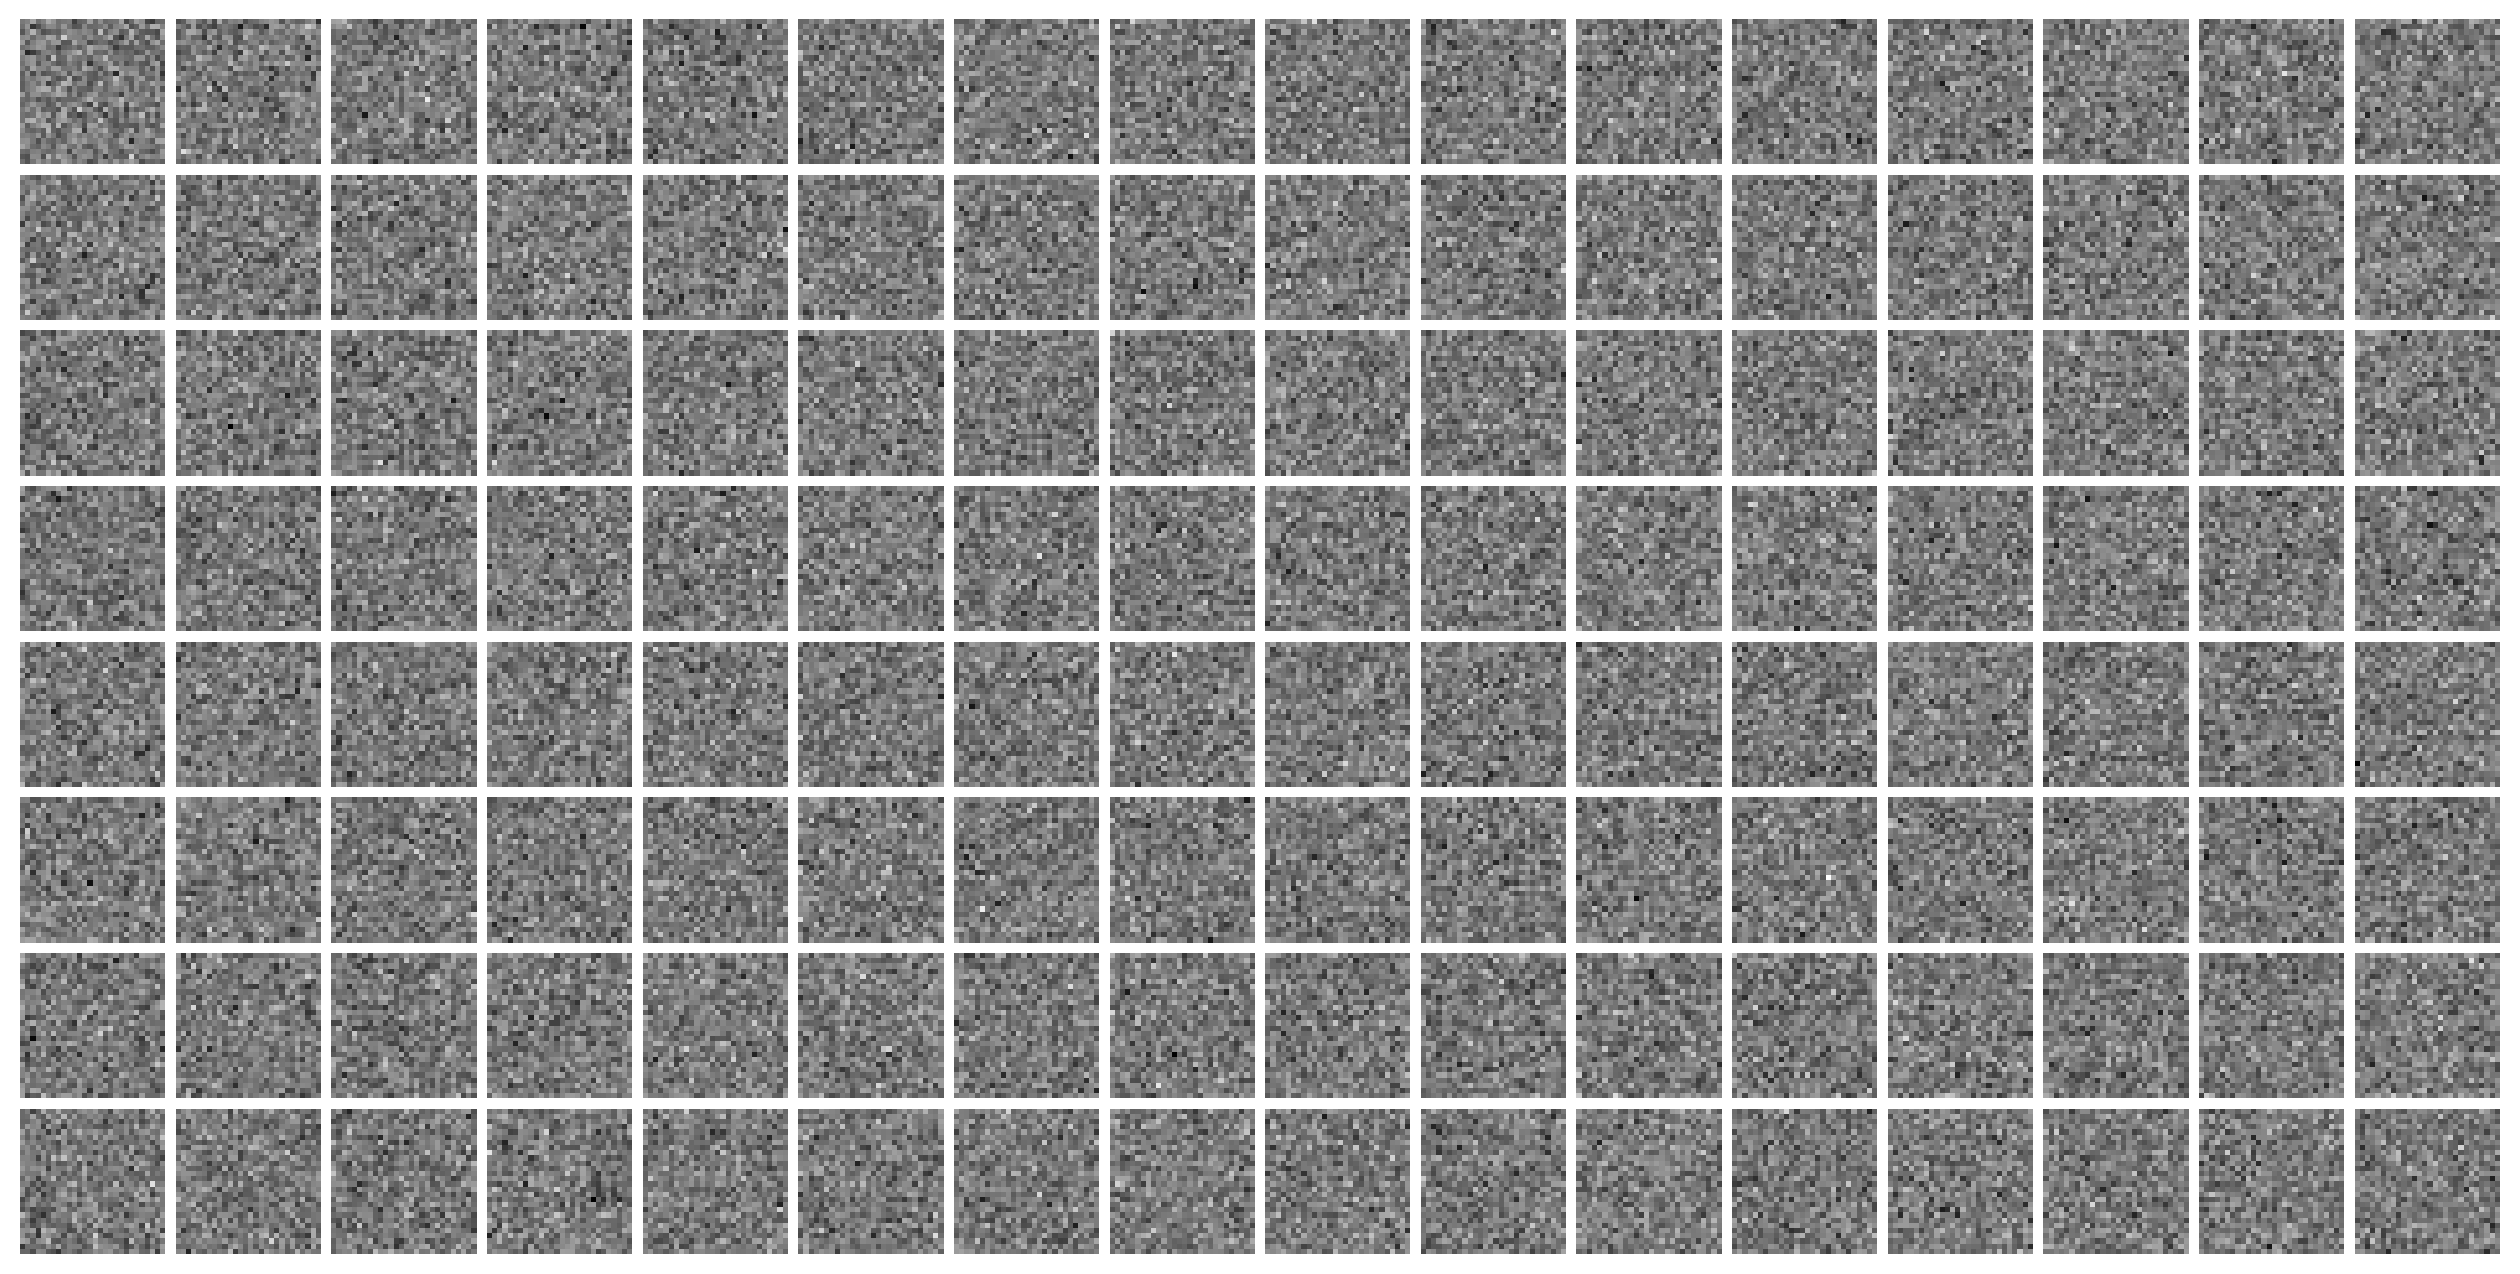

Epoch 0:	###############

C:\Users\womackow\AppData\Local\Temp\ipykernel_22636\1253528292.py:8: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-x))


######################################	elapsed: 0.82s, reconstruction error: 25.21
Epoch 1:	#####################################################	elapsed: 0.74s, reconstruction error: 19.44
Epoch 2:	#####################################################	elapsed: 0.56s, reconstruction error: 16.66
Epoch 3:	#####################################################	elapsed: 0.56s, reconstruction error: 15.03
Epoch 4:	#####################################################	elapsed: 0.55s, reconstruction error: 13.88
Epoch 5:	#####################################################	elapsed: 0.53s, reconstruction error: 12.64
Epoch 6:	#####################################################	elapsed: 0.56s, reconstruction error: 11.51
Epoch 7:	#####################################################	elapsed: 0.53s, reconstruction error: 10.82
Epoch 8:	#####################################################	elapsed: 0.53s, reconstruction error: 10.43
Epoch 9:	####################################################

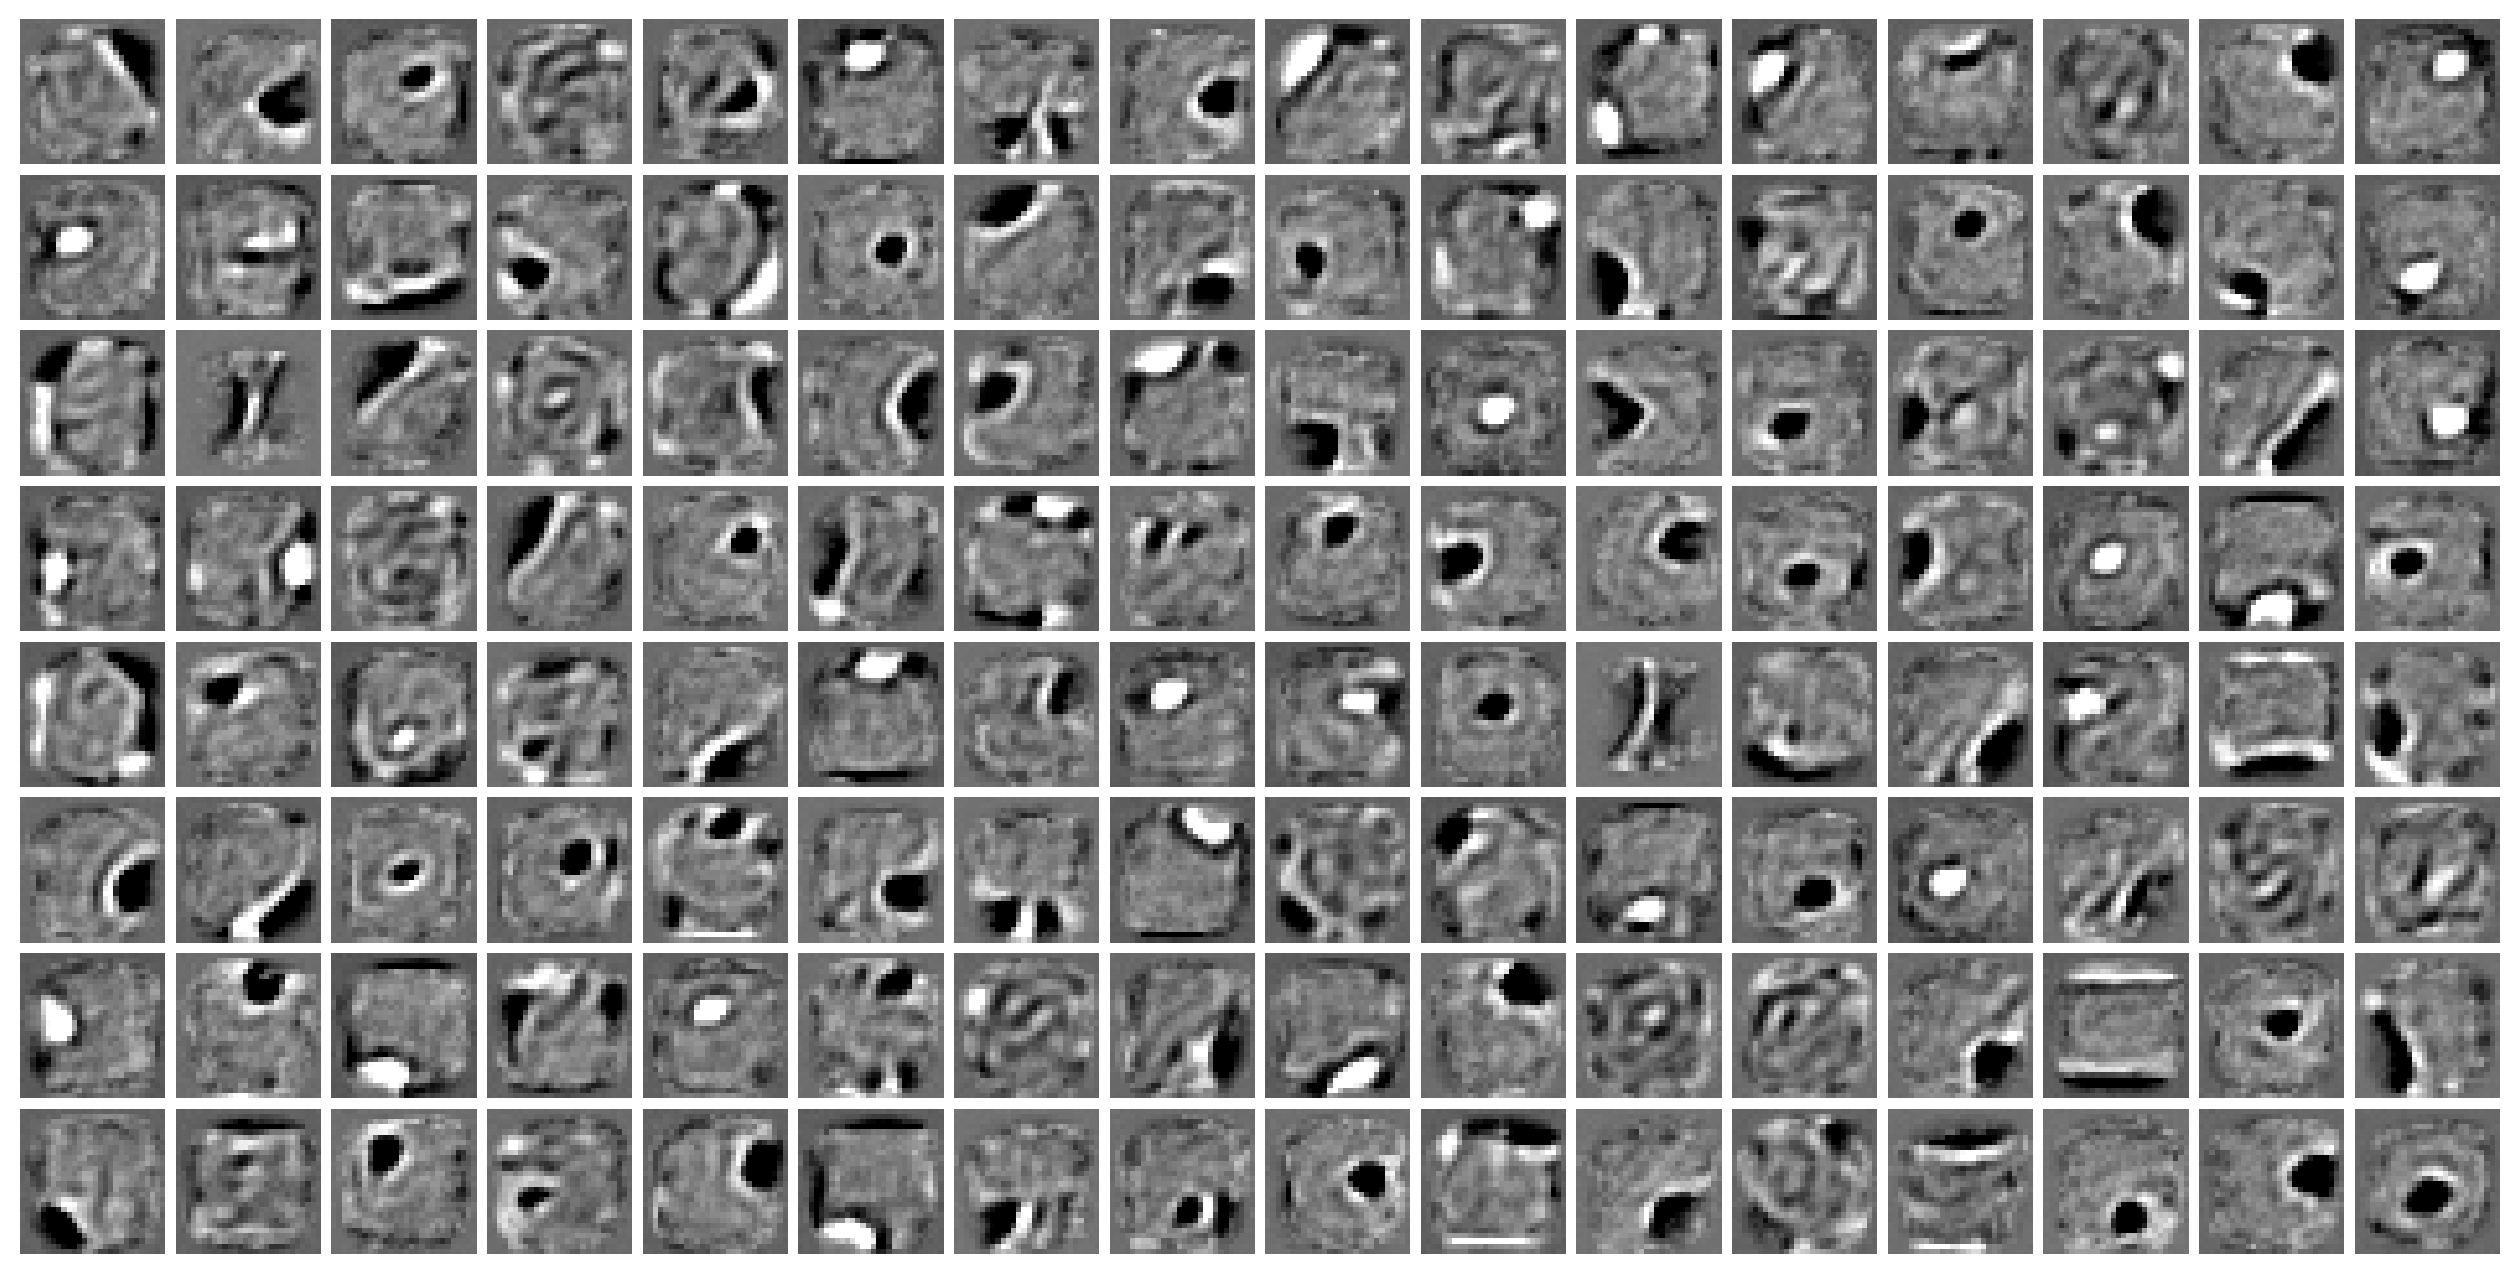

In [12]:
BATCH_SIZE: int = 128
EPOCHS_COUNT: int = 50

LEARNING_RATE = 0.1
MOMENTUM = 0.5

rbm = RestrictedBoltzmannMachine(VISIBLE_LAYER_SIZE, HIDDEN_LAYER_SIZE, LEARNING_RATE, MOMENTUM)
draw_filters(rbm)

run_training(rbm, dataset, monitoring_set, BATCH_SIZE, EPOCHS_COUNT)

draw_filters(rbm)

# 2. DBN Training

In [ ]:
from typing import TypeAlias
DBN: TypeAlias = list[RestrictedBoltzmannMachine]

def propagate_up(
    dbn: DBN,
    layers_count: int,
    visible: np.ndarray,
) -> np.ndarray:
    """
    Forward pass through DBN layers: propagates visible units upward to the target layer.
    Appends bias term (ones) and applies sigmoid activation after matrix multiplication.

    Args:
        dbn: List of RBM layers.
        layers_count: Number of layers to propagate through.
        visible: Input data (minibatch of shape [observations, visible_size]).

    Returns:
        Hidden activations at the top layer.
    """
    for i in range(layers_count):
        visible = append_ones(sigmoid(visible @ dbn[i].W[:, :-1]))
    return visible

def propagate_down(
    dbn: DBN,
    layers_count: int,
    hidden: np.ndarray,
) -> np.ndarray:
    """
    Reconstruct data by propagating downward through the DBN.
    Appends bias term (ones) and applies sigmoid activation after matrix multiplication.

    Args:
        dbn: List of RBM layers forming the DBN.
        layers_count: Number of layers to traverse downward.
        hidden: Hidden representation at the top level.

    Returns:
        Reconstructed visible representation.
    """
    for i in reversed(range(layers_count)):
        hidden = append_ones(sigmoid(hidden @ (dbn[i].W[:-1, :]).T))
    return hidden

### DBN reconstruction error

In [14]:
def reconstruction_error_specific_layer(rbm: RestrictedBoltzmannMachine, minibatch: np.ndarray) -> float:
    """
    Computes the mean per-sample reconstruction error on a minibatch.

    Runs a single forward-backward pass (encode then decode) without
    weight updates and returns the average squared difference between
    the original visible units and their reconstructions.

    Args:
        rbm:        The trained (or partially trained) RBM.
        minibatch:  A 2D float32 array of shape (n, visible_size + 1),
                    with the bias column appended.

    Returns:
        A scalar float: sum of squared errors divided by the number
        of observations.
    """

    observations_count = minibatch.shape[0]
    visible = zeros(observations_count, rbm.visible_size)
    hidden = append_ones(zeros(observations_count, rbm.hidden_size))

    # # Inline sigmoid with clipping to prevent np.exp overflow
    # def sigmoid(x):
    #     return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

    # =========================================================================
    # IMPLEMENTATION START
    # =========================================================================

    # 1. ENCODE: Visible -> Hidden
    # Calculate hidden probabilities P(h|v) = sigmoid(vW)
    hidden_activations = minibatch @ rbm.W #     N * h
    hidden[:] = sigmoid(hidden_activations)
    hidden[:, -1] = 1.0  # Maintain the bias term for the decode step

    # 2. DECODE: Hidden -> Visible
    # Calculate reconstructed visible probabilities P(v|h) = sigmoid(hW^T)
    visible_activations = hidden @ rbm.W.T #     N * v

    # We slice [:, :-1] to ignore the bias column coming back from the weight matrix,
    # as we only want to compare the actual visible features.
    visible[:] = sigmoid(visible_activations[:, :-1])

    # 3. COMPUTE ERROR
    # Calculate the squared difference between the original data (excluding bias)
    # and the reconstructed data.
    squared_errors = (minibatch[:, :-1] - visible) ** 2

    # Sum of all squared errors divided by the number of observations (rows)
    error = float(np.sum(squared_errors) / observations_count)

    return error

def dbn_reconstuction_error(
    dbn: DBN,
    layer_idx: int,
    minibatch: np.ndarray,
) -> float:
    """
    Compute the reconstruction error for a selected DBN layer.

    The minibatch is first propagated upward to the chosen layer,
    then the reconstruction error is evaluated for that RBM.

    Args:
        dbn: List of pretrained RBM layers.
        layer_idx: Index of the RBM layer to evaluate.
        minibatch: Input minibatch.

    Returns:
        Reconstruction error as a scalar value.
    """
    layer_input = propagate_up(dbn, layer_idx, minibatch)
    return reconstruction_error_specific_layer(dbn[layer_idx], layer_input)

### Sampling in Deep Belief Networks

In [ ]:
def sample_rbm(
    rbm: RestrictedBoltzmannMachine,
    minibatch: np.ndarray,
    steps: int,
) -> np.ndarray:
    """
    Perform Gibbs sampling in a single RBM.

    The procedure alternates between sampling hidden units from visible units
    and reconstructing visible units from hidden units for a given number of steps.

    Args:
        rbm: RBM used for sampling.
        minibatch: Initial visible minibatch.
        steps: Number of Gibbs sampling steps.

    Returns:
        Sampled visible states after the final Gibbs step.
    """

    observations_count = minibatch.shape[0]

    visible = minibatch
    hidden = append_ones(zeros(observations_count, rbm.hidden_size))

    for cd_i in range(steps):
        hidden[:, :-1] = sigmoid(visible @ rbm.W[:, :-1])
        hidden[:, :-1] = (hidden[:, :-1] > rand(observations_count, rbm.hidden_size)).astype(np.float32)

        visible[:, :-1] = sigmoid(hidden @ (rbm.W[:-1, :]).T)
        if cd_i < (steps - 1):
            visible[:, :-1] = (visible[:, :-1] > rand(observations_count, rbm.visible_size)).astype(np.float32)

    return visible

In [16]:
def sample_dbn(
    dbn: DBN,
    layer_idx: int,
    minibatch: np.ndarray,
    steps: int,
) -> np.ndarray:
    """
    Sample from a DBN by propagating upward, sampling in one RBM,
    and propagating the result back downward.

    Args:
        dbn: List of RBM layers forming the DBN.
        layer_idx: Index of the RBM layer used for sampling.
        minibatch: Input minibatch.
        steps: Number of Gibbs sampling steps in the selected RBM.

    Returns:
        Reconstructed sample in the visible space.
    """
    layer_input = propagate_up(dbn, layer_idx, minibatch)
    sampled_at_layer = sample_rbm(dbn[layer_idx], layer_input, steps)
    return propagate_down(dbn, layer_idx, sampled_at_layer)

In [17]:
def draw_layer_samples(
    dbn: DBN,
    layer_idx: int,
    minibatch: np.ndarray,
    steps: int = 200,
) -> None:
    """
    Draw and preview image samples reconstructed from a selected DBN layer.

    This helper is useful for visual inspection of generative quality.

    Args:
        dbn: List of RBM layers.
        layer_idx: Index of the sampled layer.
        minibatch: Input minibatch.
        steps: Number of Gibbs sampling steps.
    """
    samples = sample_dbn(dbn, layer_idx, minibatch, steps)
    preview_tiles(np.reshape(samples[:, :-1], (-1, 16, 28, 28)))

### Greedy layer-wise training

In [18]:
def train_dbn(
    dbn: DBN,
    layer_idx: int,
    dataset: np.ndarray,
    batch_size: int,
) -> None:
    """
    Train one DBN layer using greedy layer-wise pretraining.

    The dataset is first propagated through all previously trained layers.
    Then the selected RBM layer is trained on minibatches.

    Args:
        dbn: List of RBM layers.
        layer_idx: Index of the RBM layer to train.
        dataset: Full training dataset.
        batch_size: Minibatch size.
    """
    layer_input = propagate_up(dbn, layer_idx, dataset)
    train_epoch(dbn[layer_idx], layer_input, batch_size)

In [19]:
BATCH_SIZE: int = 128
EPOCHS_COUNT: int = 50

LEARNING_RATE: float = 0.1
MOMENTUM: float = 0.5

DBN_HIDDEN_LAYER_SIZE: int = 200

dbn: DBN = [
    RestrictedBoltzmannMachine(
        VISIBLE_LAYER_SIZE,
        DBN_HIDDEN_LAYER_SIZE,
        LEARNING_RATE,
        MOMENTUM,
    ),
    RestrictedBoltzmannMachine(
        DBN_HIDDEN_LAYER_SIZE,
        DBN_HIDDEN_LAYER_SIZE,
        LEARNING_RATE,
        MOMENTUM,
    ),
    RestrictedBoltzmannMachine(
        DBN_HIDDEN_LAYER_SIZE,
        DBN_HIDDEN_LAYER_SIZE,
        LEARNING_RATE,
        MOMENTUM,
    ),
]

for layer_idx in range(len(dbn)):
    print(f"\nLearning layer {layer_idx}")

    for epoch in range(EPOCHS_COUNT):
        print(f"Epoch {epoch}:", end="\t")

        if epoch == 5:
            dbn[layer_idx].momentum = 0.8

        start_time = time.time()
        train_dbn(dbn, layer_idx, dataset, BATCH_SIZE)
        elapsed = time.time() - start_time

        error = dbn_reconstuction_error(dbn, layer_idx, monitoring_set)
        print(f"\telapsed: {elapsed:>2.2f}s, reconstruction error: {error:>2.2f}")

print("Training finished!")


Learning layer 0
Epoch 0:	#################################

C:\Users\womackow\AppData\Local\Temp\ipykernel_22636\1253528292.py:8: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-x))


####################	elapsed: 1.92s, reconstruction error: 22.88
Epoch 1:	#####################################################	elapsed: 1.96s, reconstruction error: 17.00
Epoch 2:	#####################################################	elapsed: 1.73s, reconstruction error: 14.21
Epoch 3:	#####################################################	elapsed: 2.29s, reconstruction error: 12.60
Epoch 4:	#####################################################	elapsed: 2.02s, reconstruction error: 11.38
Epoch 5:	#####################################################	elapsed: 5.76s, reconstruction error: 10.34
Epoch 6:	#####################################################	elapsed: 6.53s, reconstruction error: 9.27
Epoch 7:	#####################################################	elapsed: 2.49s, reconstruction error: 8.61
Epoch 8:	#####################################################	elapsed: 1.92s, reconstruction error: 8.27
Epoch 9:	#####################################################	elapsed: 1.89s, rec

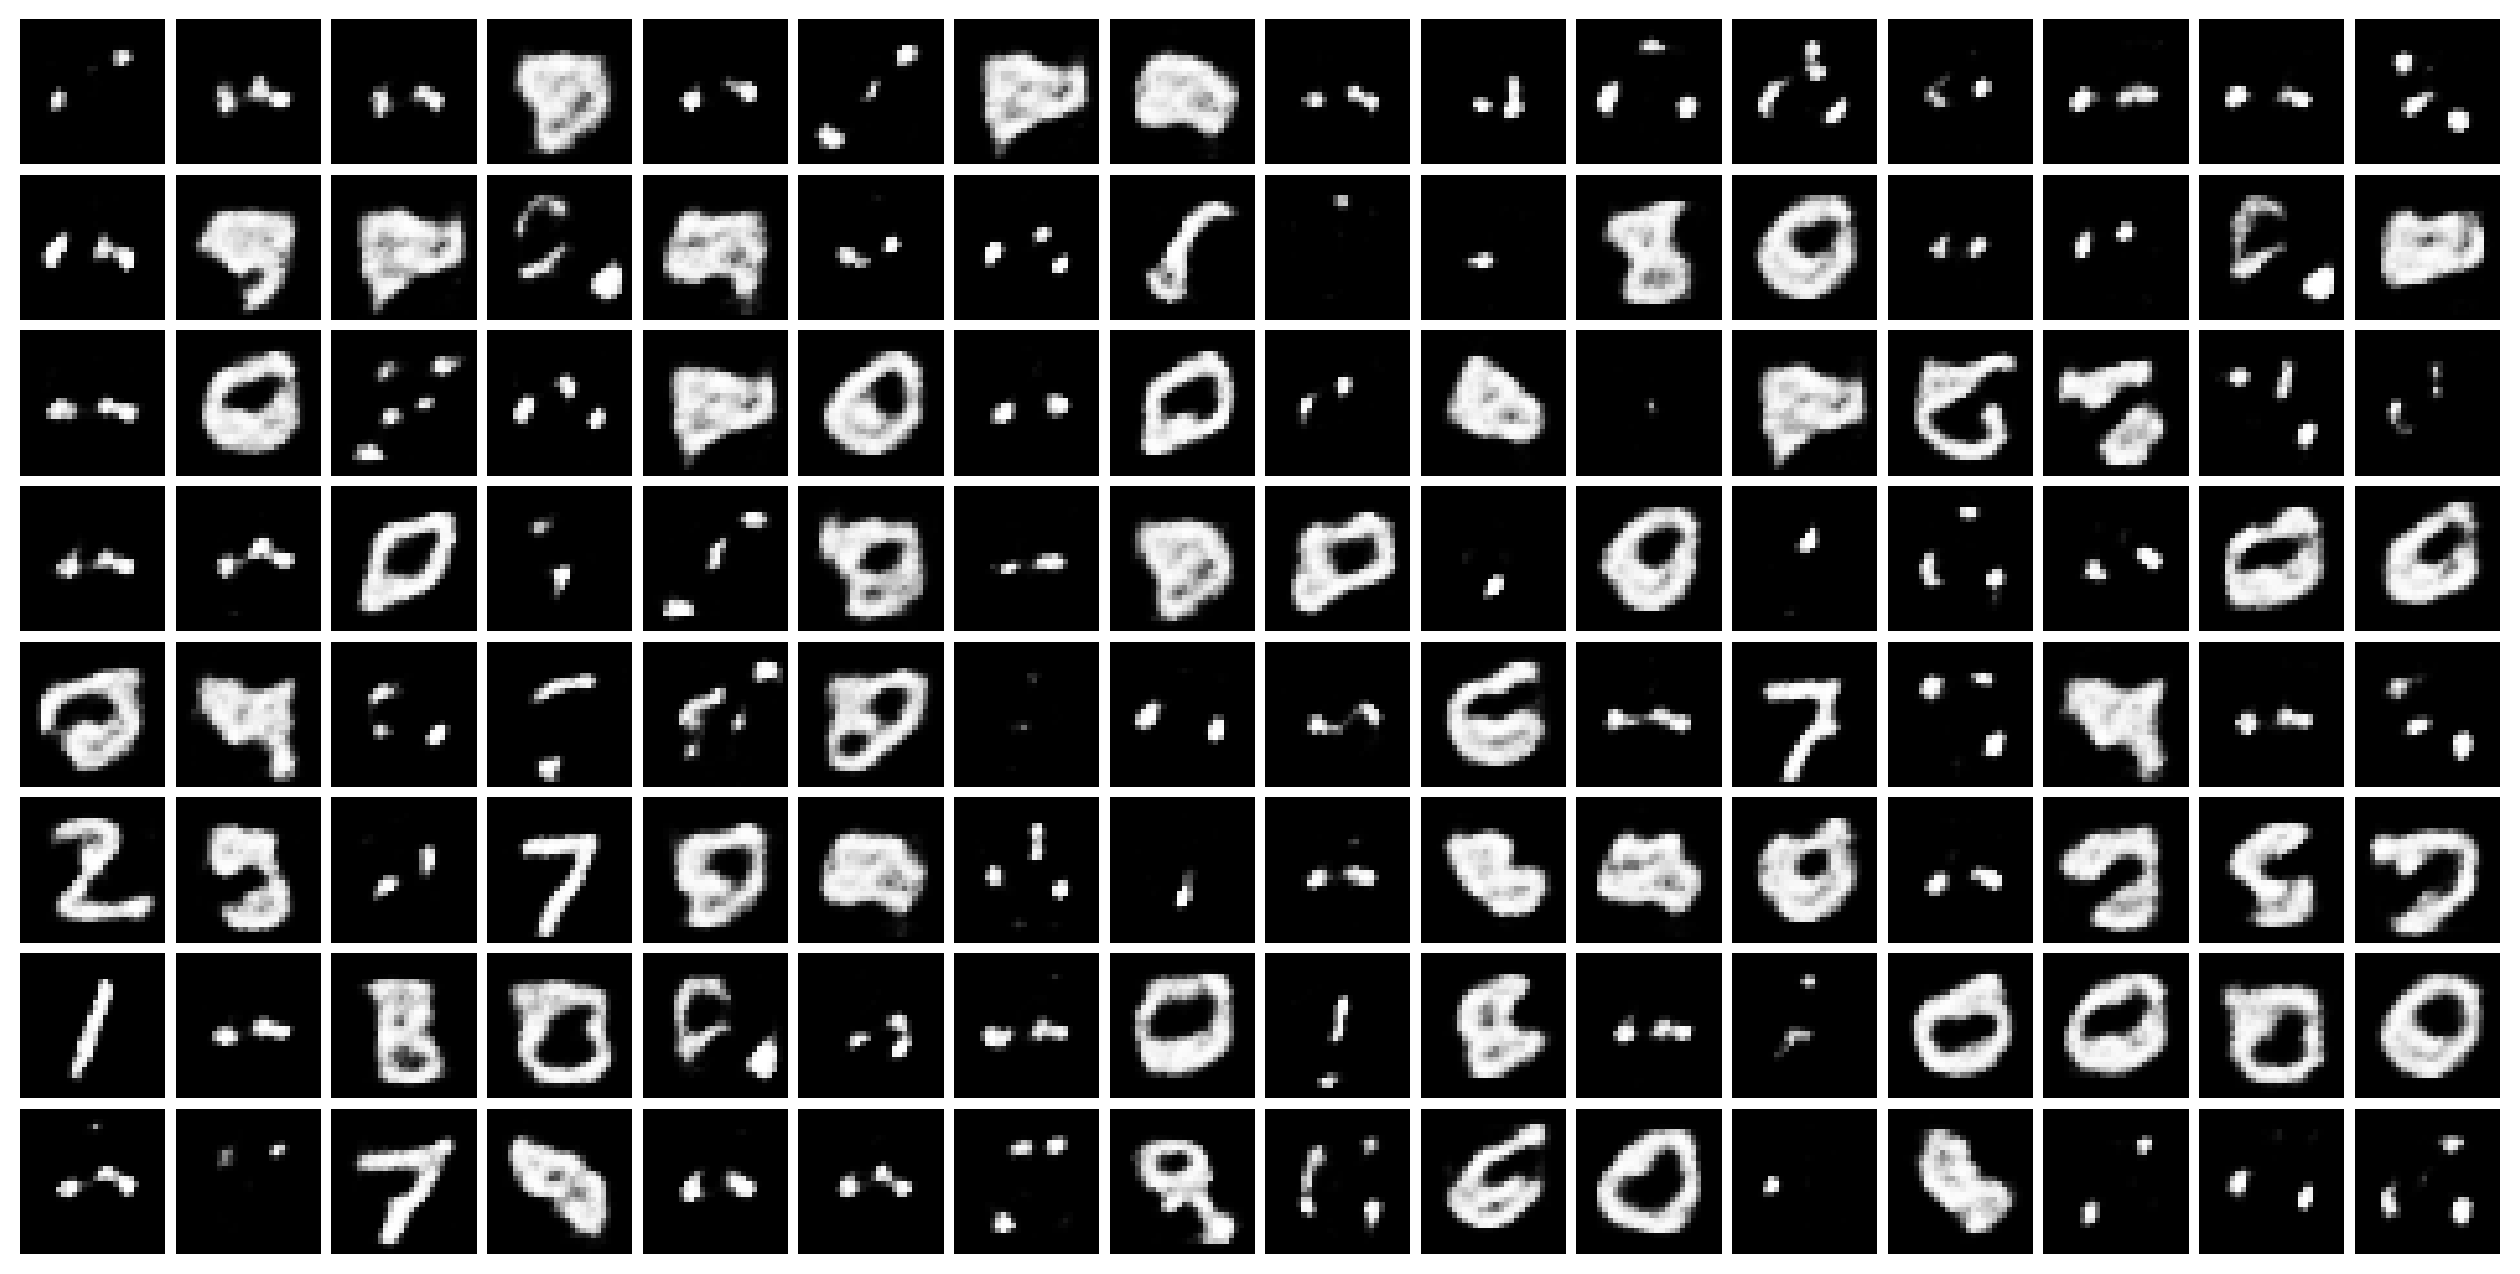

In [20]:
draw_layer_samples(dbn, 0, monitoring_set[:8*16])

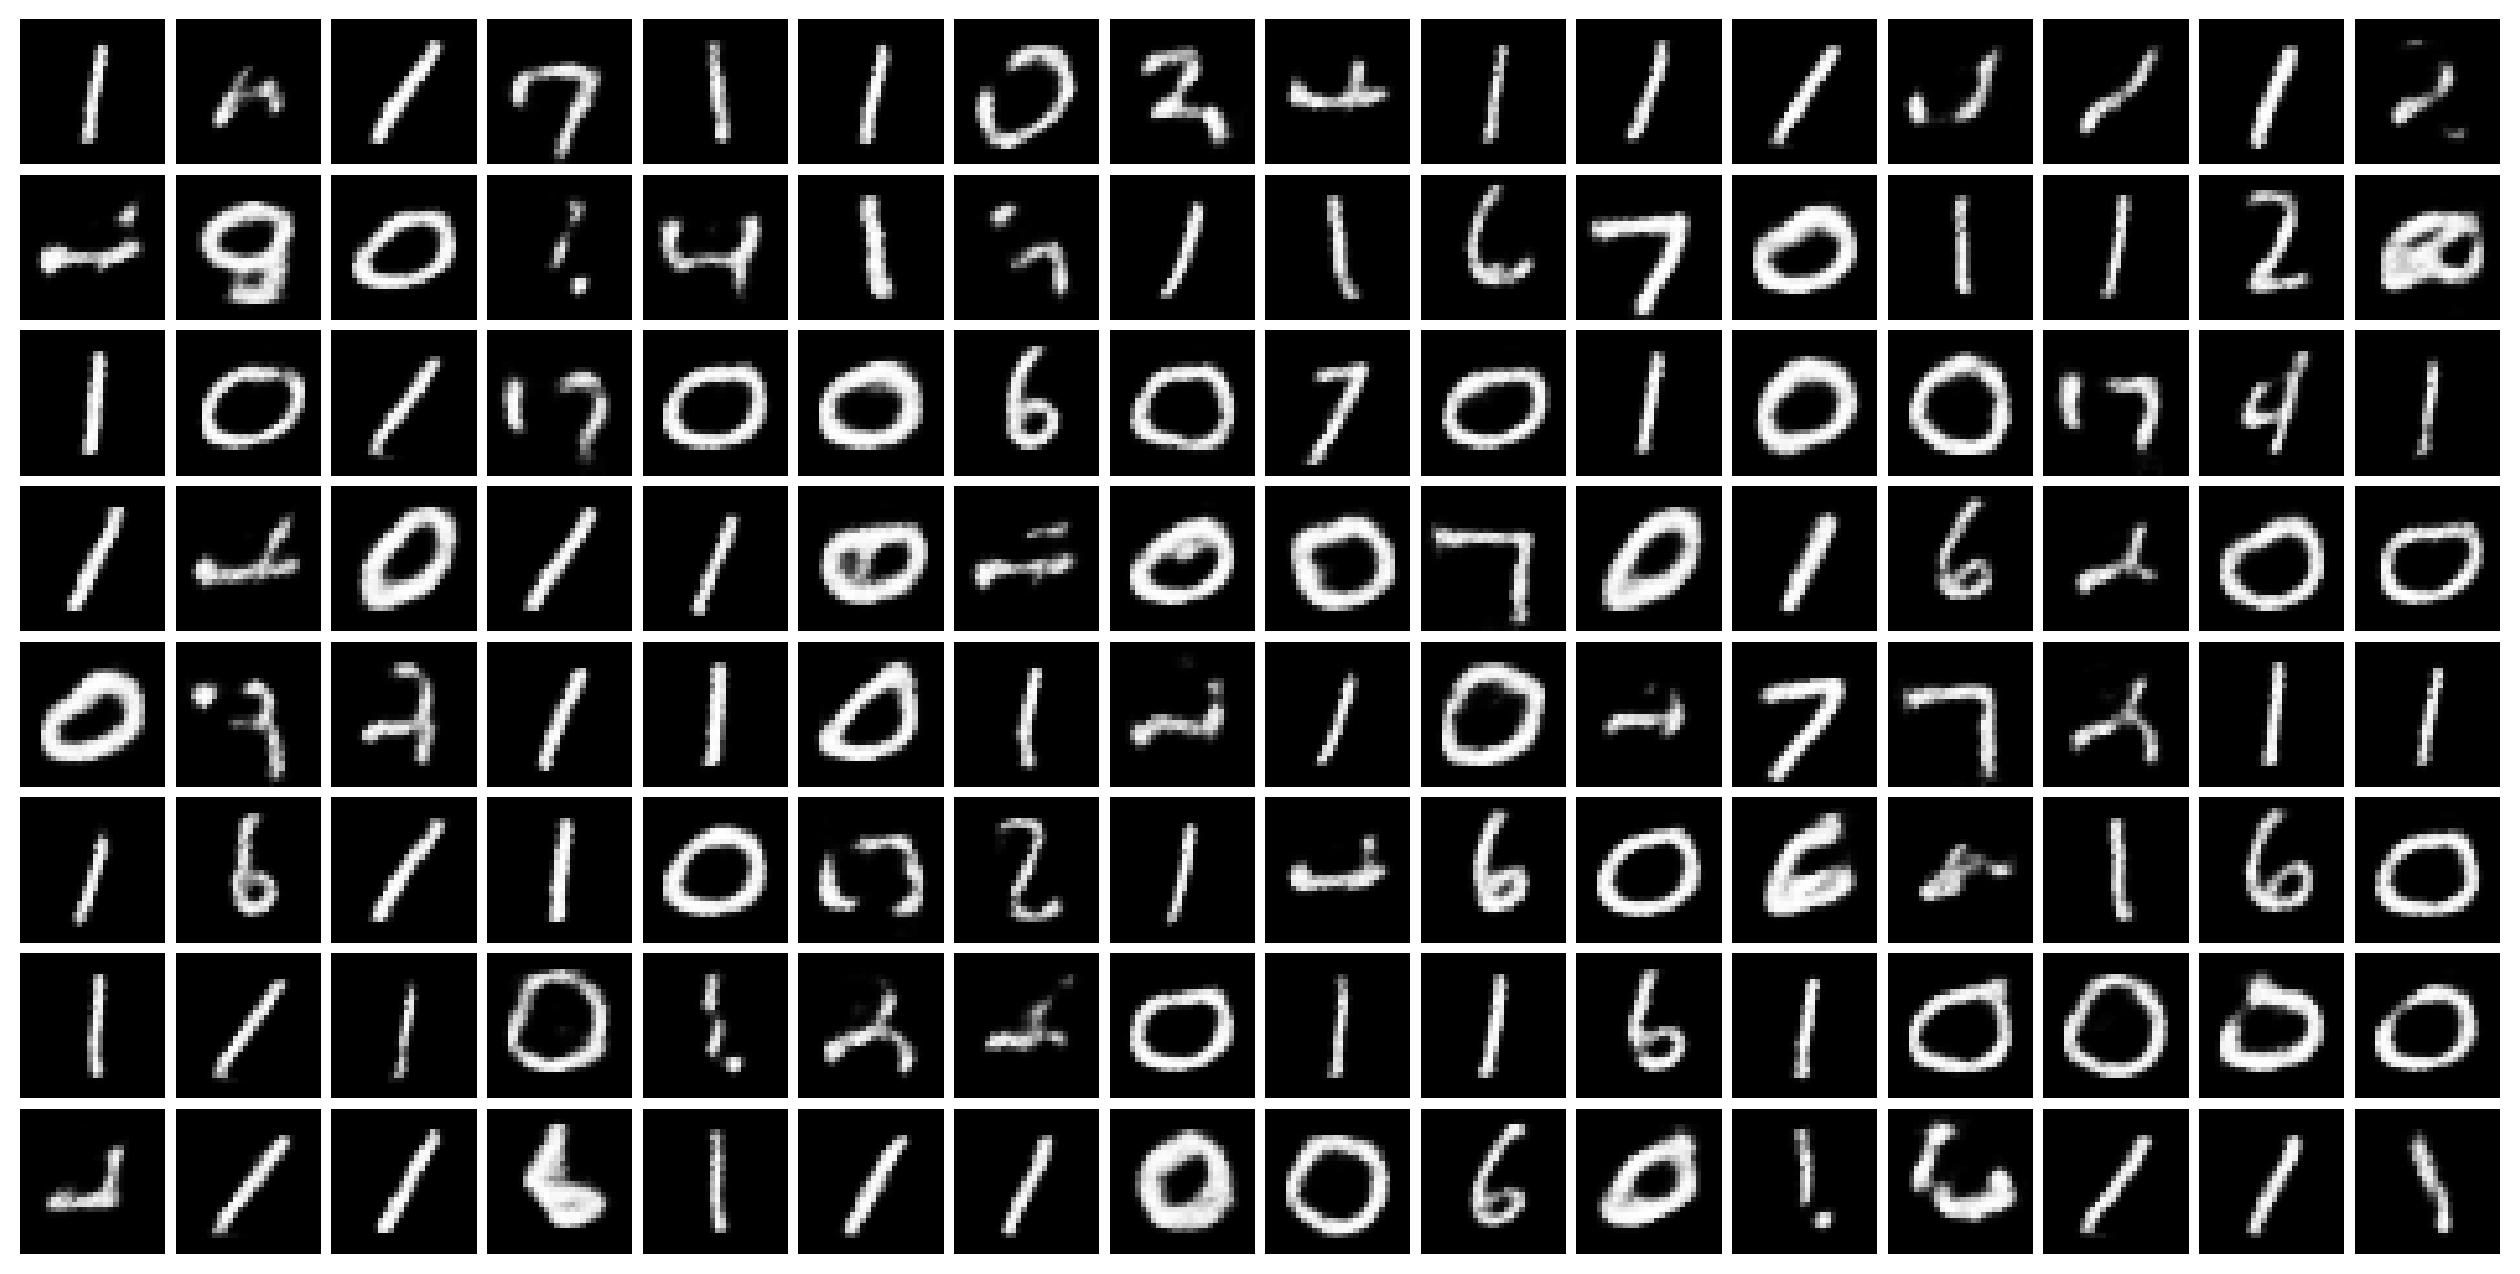

In [21]:
draw_layer_samples(dbn, 1, monitoring_set[:8*16])

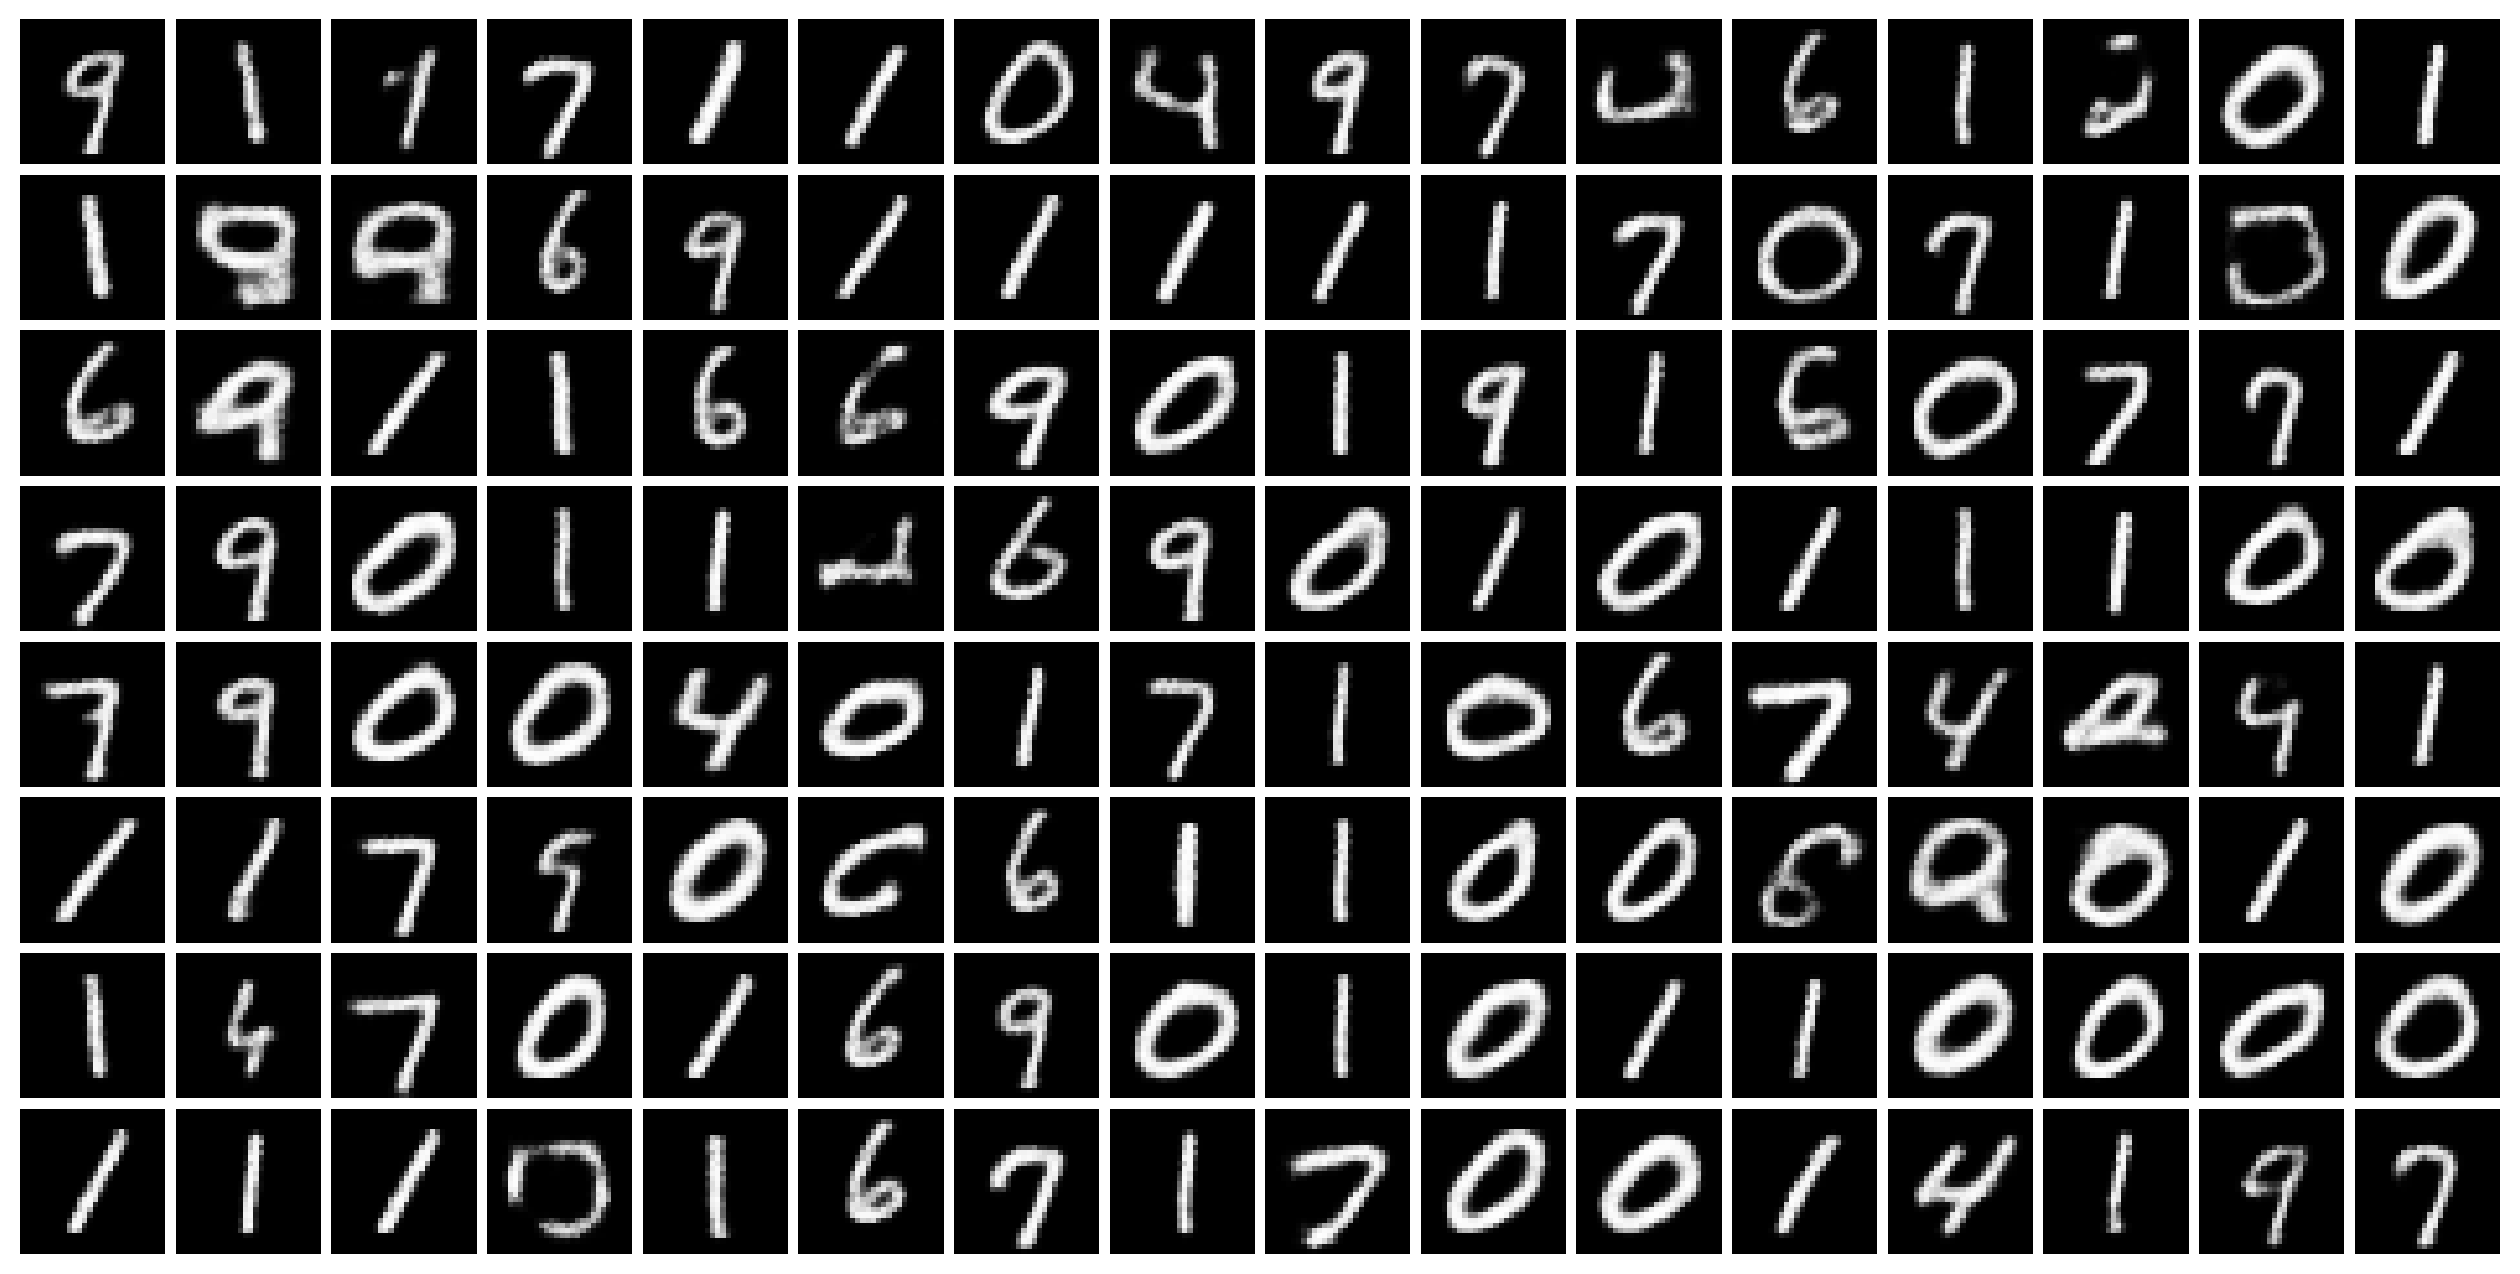

In [22]:
draw_layer_samples(dbn, 2, monitoring_set[:8*16])

## Additional links

* [YouTube - Hugo Larochelle | Neural networks [7.7] : Deep learning - deep belief network](https://www.youtube.com/watch?v=vkb6AWYXZ5I)